# 🏥 Pipeline ACL Classifier - Clean Version

Código limpio y modularizado para entrenar modelos ViT independientes por plano anatómico.

**Estructura:**
- `gpu_config.py` — Configuración de GPUs (fija para todos los planos)
- `preprocessing.py` — Cálculo de índices de slices
- `models.py` — Modelos (CNN Selector, ViT, Loss functions)
- `data_loader.py` — Dataset y transformaciones
- `training_utils.py` — Funciones de entrenamiento
- `train.ipynb` — Este notebook (config + orquestación por plano)

## 1️⃣ Imports y Configuración

In [1]:
# Imports estándar
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1,2,3'
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Módulos locales
import sys
sys.path.insert(0, '../../src')
from gpu_config import device, VIT_GPU_IDS, CNN_GPU_ID
from preprocessing import load_volume_normalized, compute_center_consecutive_indices, preprocess_slice_indices
from models import SimpleCNNSelector, ViTMultiSliceClassifier
from data_loader import OptimizedMRNetDataset, get_train_transform, get_val_test_transform
from training_utils import train_model

print("✓ Todos los módulos importados exitosamente")

GPU CONFIGURATION
Device: cuda
GPUs disponibles: 3
  GPU 0: NVIDIA H100 PCIe
    Memoria: 85.02 GB
  GPU 1: NVIDIA H100 PCIe
    Memoria: 85.02 GB
  GPU 2: NVIDIA H100 PCIe
    Memoria: 85.02 GB

📌 Asignación de GPUs:
  ViT Training: GPUs [0, 1, 2]
  CNN Pre-processing: GPU 0

✓ Todos los módulos importados exitosamente


## 2️⃣ Configuración Global

In [2]:
# ==========================================
# RUTAS Y DIRECTORIOS
# ==========================================
DATA_PATH = Path('../../data')
CHECKPOINT_DIR = Path('../../checkpoints/vit_base')
SLICE_INDICES_DIR = Path('../data/slice_indices_final')

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SLICE_INDICES_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# ESTRATEGIA DE SLICES
# ==========================================
PLANE_CONFIG = {
    'sagittal': {
        'num_slices': 5,
        'strategy': 'cnn_based',
        'pooling_mode': 'attention',
        'description': 'CNN Selector V3'
    },
    'coronal': {
        'num_slices': 10,
        'strategy': 'cnn_based',
        'pooling_mode': 'max',
        'description': 'CNN Selector Coronal'
    },
    'axial': {
        'num_slices': 10,
        'strategy': 'center_consecutive',
        'pooling_mode': 'attention',
        'description': '10 slices centrales'
    }
}

PLANES = ['sagittal', 'coronal', 'axial']
CNN_SELECTORS_PATHS = {
    'sagittal': Path('../../checkpoints/acl_slice_classifier_v3/best_model_f1.pth'),
    'coronal': Path('../../checkpoints/acl_slice_classifier_coronal/best_model_f1.pth'),
    'axial': None
}

USE_CACHED_INDICES = True
VIT_MODEL_NAME = "google/vit-base-patch16-224"
IMAGE_SIZE = 224
NUM_CLASSES = 1 # Clasificación binaria (ACL lesion vs no lesion)
BATCH_SIZE = 64
NUM_WORKERS = 8
SEED = 42
NUM_EPOCHS = 150  # AUMENTADO de 100 a 150 para mejor convergencia

# ==========================================
# CONFIGURACIÓN DE AUGMENTATION POR PLANO
# ==========================================
AUGMENTATION_MODE_PER_PLANE = {
    'sagittal': 'conservative',
    'coronal': 'moderate',
    'axial': 'aggressive'
}

# ==========================================
# CONFIGURACIÓN ESPECÍFICA POR PLANO
# ==========================================
PLANE_SPECIFIC_CONFIG = {
    'sagittal': {
        'learning_rate': 1.5e-4,  # VOLVEMOS al original (estable)
        'weight_decay': 1e-3,      # VOLVEMOS al original
        'dropout_input': 0.3,
        'dropout_dense': 0.2,
        'use_scheduler': True,
        'use_grad_clip': False,
        'early_stopping_patience': 25,  # AUMENTAMOS de 15 a 25 (más oportunidades)
        'label_smoothing': 0.05,
        'warmup_epochs': 5,  # AUMENTAMOS warmup de 3 a 5 (mejor estabilidad)
        'status': '🚀 ESTRATEGIA: Baseline Estable + 150 Epochs + Patience=25 + Warmup=5'
    },
    'coronal': {
        'learning_rate': 1.5e-4,
        'weight_decay': 1e-3,
        'dropout_input': 0.35,
        'dropout_dense': 0.25,
        'use_scheduler': True,
        'use_grad_clip': True,
        'early_stopping_patience': 15,
        'label_smoothing': 0.05,
        'status': '✅ Moderate Aug + Balanced Regularization'
    },
        'axial': {
        'learning_rate': 1.5e-4,
        'weight_decay': 4.5e-4,          # ← AUMENTAR de 1e-4 a 5e-4
        'dropout_input': 0.35,         # ← AUMENTAR de 0.2 a 0.35
        'dropout_dense': 0.25,         # ← AUMENTAR de 0.1 a 0.25
        'use_scheduler': True,
        'use_grad_clip': True,
        'early_stopping_patience': 15, # ← BAJAR de 20 a 15 (más estricto)
        'label_smoothing': 0.1,        # ← AUMENTAR de 0.05 a 0.1
        'warmup_epochs': 5,            # ← BAJAR de 3 a 2 (menos libertad inicial)
        'status': '🎯 REGULARIZACIÓN FUERTE: weight_decay=5e-4, dropout=0.35/0.25, smoothing=0.1'
    }
}

# ==========================================
# CONFIGURACIÓN DE WANDB
# ==========================================
USE_WANDB = True  # Cambiar a True si quieres usar Weights & Biases
WANDB_PROJECT = "ACL -TFG"
WANDB_ENTITY = "palodo2-universitat-de-val-ncia"

# Set random seeds
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"{'='*80}")
print(f"CONFIGURACIÓN CARGADA")
print(f"{'='*80}")
print(f"Data path: {DATA_PATH}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print(f"Slice indices dir: {SLICE_INDICES_DIR}")
print(f"Num epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Wandb enabled: {USE_WANDB}")
print(f"{'='*80}\n")

CONFIGURACIÓN CARGADA
Data path: ../../data
Checkpoint dir: ../../checkpoints/vit_base
Slice indices dir: ../data/slice_indices_final
Num epochs: 150
Batch size: 64
Wandb enabled: True



## 3️⃣ Pre-procesamiento (Opcional)

In [ ]:
# Ejecutar SOLO SI los índices no están cacheados o quieres recalcularlos
PREPROCESS = True  # ✅ REGENERAR ÍNDICES para solucionar KeyError

if PREPROCESS:
    # Cargar CNN Selectors
    cnn_selectors = {}
    for plane in PLANES:
        cnn_path = CNN_SELECTORS_PATHS.get(plane)
        if cnn_path and cnn_path.exists() and PLANE_CONFIG[plane]['strategy'] == 'cnn_based':
            cnn_selectors[plane] = SimpleCNNSelector(
                cnn_path,
                device=f'cuda:{CNN_GPU_ID}'
            )
            print(f"✓ CNN Selector para {plane} cargado")
        else:
            cnn_selectors[plane] = None
    
    # Ejecutar pre-procesamiento
    preprocess_slice_indices(
        data_path=DATA_PATH,
        slice_indices_dir=SLICE_INDICES_DIR,
        plane_config=PLANE_CONFIG,
        cnn_selectors=cnn_selectors,
        use_cached_indices=USE_CACHED_INDICES,
        splits=['train', 'val', 'test']
    )
else:
    print("⏭️  Saltando pre-procesamiento (usando índices cacheados)")

PRE-PROCESSING: CÁLCULO DE ÍNDICES DE SLICES (MULTI-CNN)

Estrategia por plano:
  • Sagittal: K=5 (CNN Selector V3 - GPU acelerada)
  • Coronal: K=10 (CNN Selector Coronal - GPU acelerada)
  • Axial: K=10 (slices centrales consecutivos)



PROCESANDO SPLIT: TRAIN

[SAGITTAL] ✓ Usando índices cacheados: train_sagittal_indices.json
[CORONAL] ✓ Usando índices cacheados: train_coronal_indices.json
[AXIAL] ✓ Usando índices cacheados: train_axial_indices.json

PROCESANDO SPLIT: VAL

[SAGITTAL] ✓ Usando índices cacheados: val_sagittal_indices.json
[CORONAL] ✓ Usando índices cacheados: val_coronal_indices.json
[AXIAL] ✓ Usando índices cacheados: val_axial_indices.json

PROCESANDO SPLIT: TEST

[SAGITTAL] ✓ Usando índices cacheados: test_sagittal_indices.json
[CORONAL] ✓ Usando índices cacheados: test_coronal_indices.json
[AXIAL] ✓ Usando índices cacheados: test_axial_indices.json

✓ PRE-PROCESAMIENTO COMPLETADO



## 4️⃣ Entrenar SAGITTAL

In [3]:

train_sagittal= True # Cambiar a True para entrenar el plano sagital
if train_sagittal:
    plane = 'sagittal'
    print(f"\n{'='*80}")
    print(f"🔄 ENTRENANDO: {plane.upper()}")
    print(f"{'='*80}\n")

    # Cargar configuración
    cfg = PLANE_SPECIFIC_CONFIG[plane]
    aug_mode = AUGMENTATION_MODE_PER_PLANE[plane]
    plane_pooling_mode = PLANE_CONFIG[plane].get('pooling_mode', 'attention')

    # Crear datasets
    train_indices_path = SLICE_INDICES_DIR / f"train_{plane}_indices.json"
    val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"

    train_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'train-acl.csv',
        data_root=DATA_PATH / 'train',
        plane=plane,
        indices_cache_path=train_indices_path,
        augmentation_mode=aug_mode
    )

    val_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

    # Crear DataLoaders
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
        num_workers=NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    print(f"✓ DataLoaders creados:")
    print(f"  Train: {len(train_loader)} batches ({len(train_dataset)} casos)")
    print(f"  Val: {len(val_loader)} batches ({len(val_dataset)} casos)\n")

    # Crear modelo
    model = ViTMultiSliceClassifier(
        model_name=VIT_MODEL_NAME,
        num_classes=NUM_CLASSES,
        pretrained=True,
        pooling_mode=plane_pooling_mode,
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense']
    )

    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
    model = model.to(device)

    print(f"✓ Modelo ViT en GPUs: {VIT_GPU_IDS}\n")

    # Entrenar
    history, best_auc, best_f1 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        device=device,
        save_dir=CHECKPOINT_DIR,
        plane_name=plane,
        learning_rate=cfg['learning_rate'],
        weight_decay=cfg['weight_decay'],
        label_smoothing=cfg.get('label_smoothing', 0.05),
        use_scheduler=cfg.get('use_scheduler', False),
        use_grad_clip=cfg.get('use_grad_clip', False),
        early_stopping_patience=cfg.get('early_stopping_patience', 15),
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense'],
        augmentation_mode=aug_mode,
        use_wandb=USE_WANDB,
        warmup_epochs=cfg.get('warmup_epochs', 3)
    )

    print(f"\n{'='*80}")
    print(f"✅ SAGITTAL COMPLETADO")
    print(f"   Best AUC: {best_auc:.4f}")
    print(f"   Best F1: {best_f1:.4f}")
    print(f"{'='*80}\n")


🔄 ENTRENANDO: SAGITTAL

✓ Dataset cargado: 875 casos
  Plane: sagittal
  Augmentation: conservative
  Índices cacheados: ../data/slice_indices_final/train_sagittal_indices.json
✓ Dataset cargado: 188 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/val_sagittal_indices.json
✓ DataLoaders creados:
  Train: 14 batches (875 casos)
  Val: 3 batches (188 casos)



Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Modelo ViT en GPUs: [0, 1, 2]


ENTRENANDO MODELO: SAGITTAL
LR=0.00015, WD=0.001, Scheduler=True, GradClip=False
Dropout: Input=0.3, Dense=0.2
Augmentation: conservative



wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/palodo2/.netrc.


📊 Class imbalance (pos_weight): 3.7814
   (Ratio negatives:positives)



wandb: Currently logged in as: palodo2 (palodo2-universitat-de-val-ncia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✓ Weights & Biases inicializado para sagittal

Epoch 1/150 (LR=3.00e-05): Train: Loss=1.1331, AUC=0.5157 | Val: Loss=1.0549, AUC=0.7515, F1=0.3396 ✓ Best AUC!
Epoch 2/150 (LR=6.00e-05): Train: Loss=1.0615, AUC=0.6635 | Val: Loss=0.9555, AUC=0.8074, F1=0.4336 ✓ Best AUC!
Epoch 3/150 (LR=9.00e-05): Train: Loss=1.0165, AUC=0.7301 | Val: Loss=0.9150, AUC=0.8191, F1=0.5679 ✓ Best AUC!
Epoch 4/150 (LR=1.20e-04): Train: Loss=0.9111, AUC=0.8105 | Val: Loss=0.8302, AUC=0.8606, F1=0.6019 ✓ Best AUC!
Epoch 5/150 (LR=1.50e-04): Train: Loss=0.9116, AUC=0.8211 | Val: Loss=0.8232, AUC=0.8575, F1=0.5882
Epoch 6/150 (LR=1.50e-04): Train: Loss=0.7428, AUC=0.9081 | Val: Loss=0.7547, AUC=0.9064, F1=0.5962 ✓ Best AUC!
Epoch 7/150 (LR=1.50e-04): Train: Loss=0.6358, AUC=0.9443 | Val: Loss=0.6809, AUC=0.9211, F1=0.6593 ✓ Best AUC!
Epoch 8/150 (LR=1.50e-04): Train: Loss=0.5728, AUC=0.9589 | Val: Loss=0.9519, AUC=0.9375, F1=0.5691 ✓ Best AUC!
Epoch 9/150 (LR=1.50e-04): Train: Loss=0.6378, AUC=0.9428 | Val: Loss

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,▁▃▄▆███████████████████████▇▇▇▇▇▇▇▇▇▇▇▇
train_auc,▁▃▄▅▅▇▇▇▇▇█████████████████████████████
train_loss,█▇▇▆▆▅▄▃▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_auc,▁▃▃▅▅▆▇▇▇▇▇▆▇█▇▆▅▇▇▇▆█▇▆▇▇▇▇▇▇▇▇▇▇▆▇▇▆▆
val_f1,▁▂▄▅▅▅▆▄█▆▅▇▆██▇▆▇█▅▆▇▇▇▆▇▆▇▇█▇▇█▇▇▆█▇▆
val_loss,█▆▆▄▄▃▂▆▂▂▃▃▃▁▂▄▇▃▂▅▄▂▃▅▆▂▅▃▂▂▃▂▂▃▄▅▂▄▄
best_auc,0.95852
best_f1,0.80519
epoch,39
learning_rate,0.00013



✅ SAGITTAL COMPLETADO
   Best AUC: 0.9585
   Best F1: 0.8052




📊 RESULTADOS DE LA MEJOR ÉPOCA: 14
✓ Val AUC:        0.9585
✓ Val F1:         0.8052
✓ Val Loss:       0.6273
✓ Train Loss:     0.4748
✓ Learning Rate:  1.49e-04



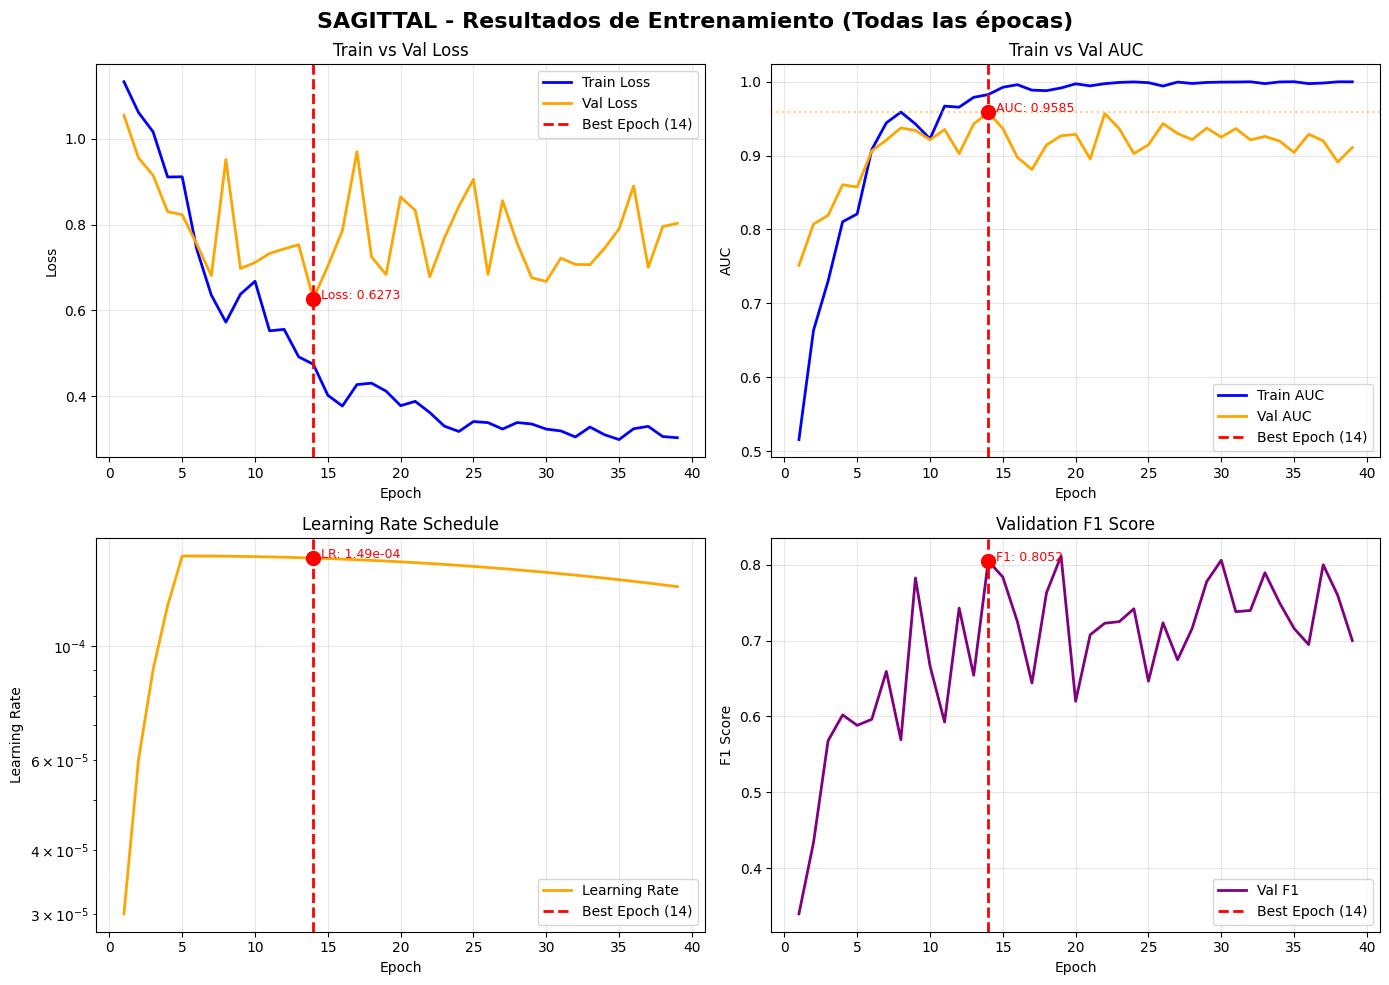

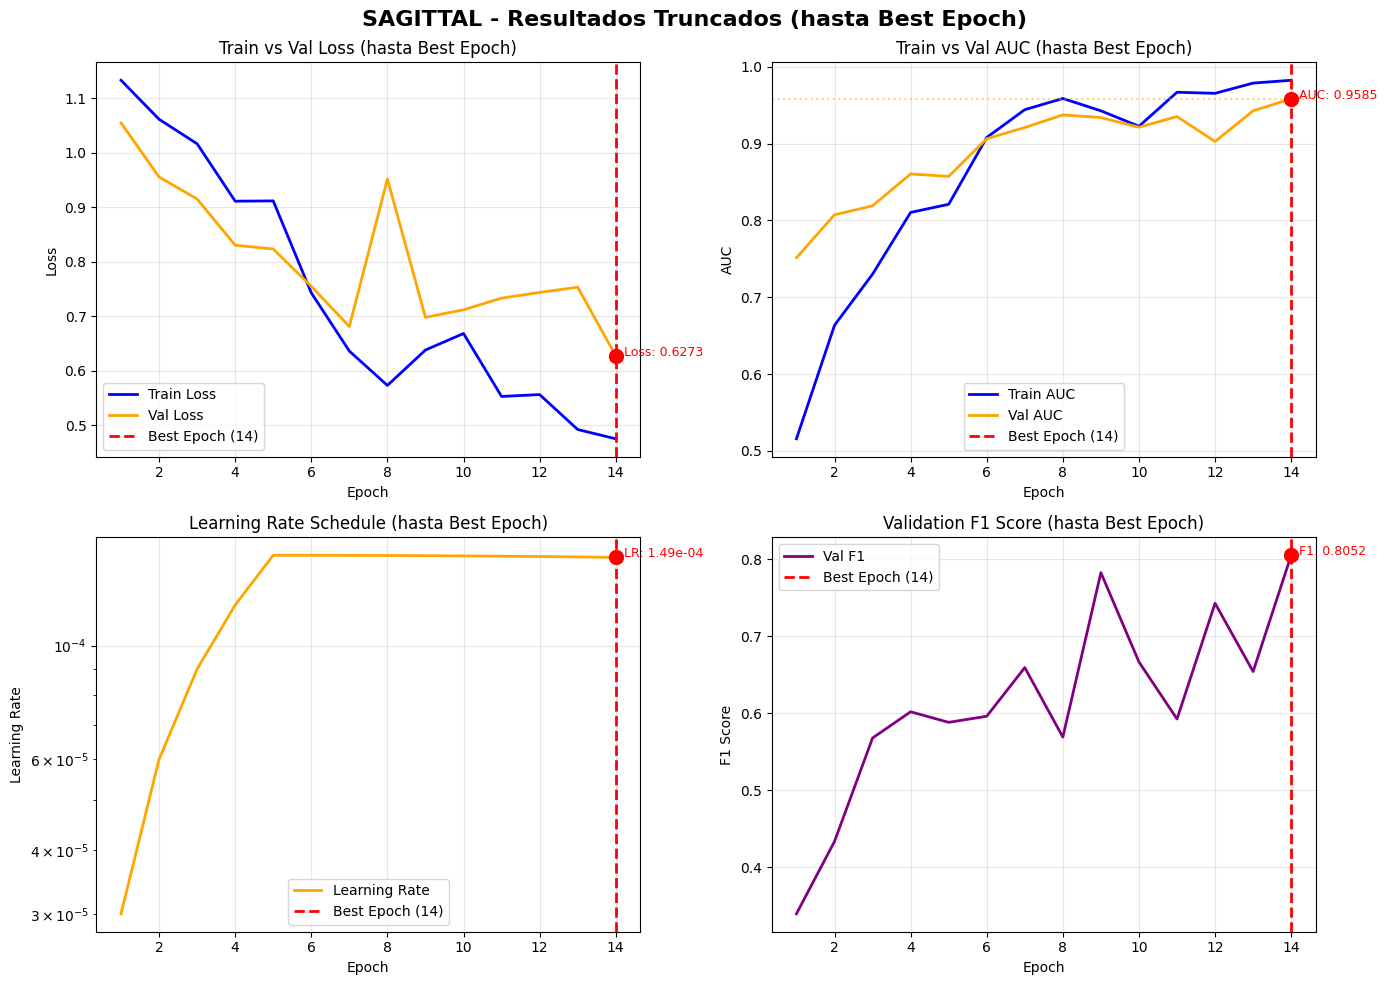

✅ Gráficos generados para SAGITTAL


In [4]:
# ==========================================
# VISUALIZACIÓN DE RESULTADOS
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# Encontrar la mejor época
best_epoch_idx = np.argmax(history['val_auc'])
best_epoch = best_epoch_idx + 1

# Obtener métricas de la mejor época
best_auc = history['val_auc'][best_epoch_idx]
best_f1 = history['val_f1'][best_epoch_idx]
best_loss = history['val_loss_objective'][best_epoch_idx]
best_train_loss = history['train_loss'][best_epoch_idx]
best_lr = history['learning_rates'][best_epoch_idx]

print(f"\n{'='*80}")
print(f"📊 RESULTADOS DE LA MEJOR ÉPOCA: {best_epoch}")
print(f"{'='*80}")
print(f"✓ Val AUC:        {best_auc:.4f}")
print(f"✓ Val F1:         {best_f1:.4f}")
print(f"✓ Val Loss:       {best_loss:.4f}")
print(f"✓ Train Loss:     {best_train_loss:.4f}")
print(f"✓ Learning Rate:  {best_lr:.2e}")
print(f"{'='*80}\n")

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{plane.upper()} - Resultados de Entrenamiento (Todas las épocas)', fontsize=16, fontweight='bold')

# 1. Train vs Val Loss
ax = axes[0, 0]
ax.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss', linewidth=2, color='blue')
ax.plot(range(1, len(history['val_loss_objective']) + 1), history['val_loss_objective'], label='Val Loss', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_loss], color='red', s=100, zorder=5)
ax.text(best_epoch, best_loss, f'  Loss: {best_loss:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Train vs Val Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. AUC - TRAIN AZUL, VAL NARANJA
ax = axes[0, 1]
ax.plot(range(1, len(history['train_auc']) + 1), history['train_auc'], label='Train AUC', linewidth=2, color='blue')
ax.plot(range(1, len(history['val_auc']) + 1), history['val_auc'], label='Val AUC', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.axhline(max(history['val_auc']), color='orange', linestyle=':', alpha=0.5)
ax.scatter([best_epoch], [best_auc], color='red', s=100, zorder=5)
ax.text(best_epoch, best_auc, f'  AUC: {best_auc:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('Train vs Val AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Learning Rate
ax = axes[1, 0]
ax.plot(range(1, len(history['learning_rates']) + 1), history['learning_rates'], label='Learning Rate', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_lr], color='red', s=100, zorder=5)
ax.text(best_epoch, best_lr, f'  LR: {best_lr:.2e}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. F1 Score
ax = axes[1, 1]
ax.plot(range(1, len(history['val_f1']) + 1), history['val_f1'], label='Val F1', linewidth=2, color='purple')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_f1], color='red', s=100, zorder=5)
ax.text(best_epoch, best_f1, f'  F1: {best_f1:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1 Score')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICOS TRUNCADOS (hasta mejor época)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{plane.upper()} - Resultados Truncados (hasta Best Epoch)', fontsize=16, fontweight='bold')

# 1. Train vs Val Loss (Truncado)
ax = axes[0, 0]
ax.plot(range(1, best_epoch + 1), history['train_loss'][:best_epoch], label='Train Loss', linewidth=2, color='blue')
ax.plot(range(1, best_epoch + 1), history['val_loss_objective'][:best_epoch], label='Val Loss', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_loss], color='red', s=100, zorder=5)
ax.text(best_epoch, best_loss, f'  Loss: {best_loss:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Train vs Val Loss (hasta Best Epoch)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. AUC (Truncado) - TRAIN AZUL, VAL NARANJA
ax = axes[0, 1]
ax.plot(range(1, best_epoch + 1), history['train_auc'][:best_epoch], label='Train AUC', linewidth=2, color='blue')
ax.plot(range(1, best_epoch + 1), history['val_auc'][:best_epoch], label='Val AUC', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.axhline(max(history['val_auc'][:best_epoch]), color='orange', linestyle=':', alpha=0.5)
ax.scatter([best_epoch], [best_auc], color='red', s=100, zorder=5)
ax.text(best_epoch, best_auc, f'  AUC: {best_auc:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('Train vs Val AUC (hasta Best Epoch)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Learning Rate (Truncado)
ax = axes[1, 0]
ax.plot(range(1, best_epoch + 1), history['learning_rates'][:best_epoch], label='Learning Rate', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_lr], color='red', s=100, zorder=5)
ax.text(best_epoch, best_lr, f'  LR: {best_lr:.2e}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule (hasta Best Epoch)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. F1 Score (Truncado)
ax = axes[1, 1]
ax.plot(range(1, best_epoch + 1), history['val_f1'][:best_epoch], label='Val F1', linewidth=2, color='purple')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_f1], color='red', s=100, zorder=5)
ax.text(best_epoch, best_f1, f'  F1: {best_f1:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1 Score (hasta Best Epoch)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✅ Gráficos generados para {plane.upper()}")

## 5️⃣ Entrenar CORONAL

In [6]:
train_coronal = True # Cambiar a True para entrenar el plano coronal
if train_coronal:
    plane = 'coronal'
    print(f"\n{'='*80}")
    print(f"🔄 ENTRENANDO: {plane.upper()}")
    print(f"{'='*80}\n")

    # Cargar configuración
    cfg = PLANE_SPECIFIC_CONFIG[plane]
    aug_mode = AUGMENTATION_MODE_PER_PLANE[plane]
    plane_pooling_mode = PLANE_CONFIG[plane].get('pooling_mode', 'attention')

    # Crear datasets
    train_indices_path = SLICE_INDICES_DIR / f"train_{plane}_indices.json"
    val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"

    train_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'train-acl.csv',
        data_root=DATA_PATH / 'train',
        plane=plane,
        indices_cache_path=train_indices_path,
        augmentation_mode=aug_mode
    )

    val_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

    # Crear DataLoaders
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
        num_workers=NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    print(f"✓ DataLoaders creados:")
    print(f"  Train: {len(train_loader)} batches ({len(train_dataset)} casos)")
    print(f"  Val: {len(val_loader)} batches ({len(val_dataset)} casos)\n")

    # Crear modelo
    model = ViTMultiSliceClassifier(
        model_name=VIT_MODEL_NAME,
        num_classes=NUM_CLASSES,
        pretrained=True,
        pooling_mode=plane_pooling_mode,
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense']
    )

    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
    model = model.to(device)

    print(f"✓ Modelo ViT en GPUs: {VIT_GPU_IDS}\n")


    # Entrenar
    history, best_auc, best_f1 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        device=device,
        save_dir=CHECKPOINT_DIR,
        plane_name=plane,
        learning_rate=cfg['learning_rate'],
        weight_decay=cfg['weight_decay'],
        label_smoothing=cfg.get('label_smoothing', 0.05),
        use_scheduler=cfg.get('use_scheduler', False),
        use_grad_clip=cfg.get('use_grad_clip', False),
        early_stopping_patience=cfg.get('early_stopping_patience', 15),
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense'],
        augmentation_mode=aug_mode,
        use_wandb=USE_WANDB,
        warmup_epochs=cfg.get('warmup_epochs', 3)
    )


🔄 ENTRENANDO: CORONAL

✓ Dataset cargado: 875 casos
  Plane: coronal
  Augmentation: moderate
  Índices cacheados: ../data/slice_indices_final/train_coronal_indices.json
✓ Dataset cargado: 188 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/val_coronal_indices.json
✓ DataLoaders creados:
  Train: 14 batches (875 casos)
  Val: 3 batches (188 casos)



Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Modelo ViT en GPUs: [0, 1, 2]


ENTRENANDO MODELO: CORONAL
LR=0.00015, WD=0.001, Scheduler=True, GradClip=True
Dropout: Input=0.35, Dense=0.25
Augmentation: moderate

📊 Class imbalance (pos_weight): 3.7814
   (Ratio negatives:positives)



✓ Weights & Biases inicializado para coronal

Epoch 1/150 (LR=5.00e-05): Train: Loss=1.1458, AUC=0.5145 | Val: Loss=1.0786, AUC=0.6122, F1=0.3377 ✓ Best AUC!
Epoch 2/150 (LR=1.00e-04): Train: Loss=1.1106, AUC=0.5984 | Val: Loss=1.0566, AUC=0.6979, F1=0.3556 ✓ Best AUC!
Epoch 3/150 (LR=1.50e-04): Train: Loss=1.0804, AUC=0.6495 | Val: Loss=0.9931, AUC=0.7454, F1=0.4615 ✓ Best AUC!
Epoch 4/150 (LR=1.50e-04): Train: Loss=1.1045, AUC=0.6367 | Val: Loss=1.0393, AUC=0.7527, F1=0.3548 ✓ Best AUC!
Epoch 5/150 (LR=1.50e-04): Train: Loss=0.9676, AUC=0.7639 | Val: Loss=0.8874, AUC=0.8542, F1=0.4640 ✓ Best AUC!
Epoch 6/150 (LR=1.50e-04): Train: Loss=0.8037, AUC=0.8750 | Val: Loss=0.7820, AUC=0.8772, F1=0.6400 ✓ Best AUC!
Epoch 7/150 (LR=1.50e-04): Train: Loss=0.7987, AUC=0.8768 | Val: Loss=0.8313, AUC=0.8357, F1=0.5287
Epoch 8/150 (LR=1.50e-04): Train: Loss=0.8449, AUC=0.8602 | Val: Loss=0.9235, AUC=0.8512, F1=0.4667
Epoch 9/150 (LR=1.49e-04): Train: Loss=0.7965, AUC=0.8791 | Val: Loss=0.7746, AUC=

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
learning_rate,▁▄█████████████████████▇▇▇▇▇▇▇▇▇▇▇▇▇
train_auc,▁▂▃▃▅▆▆▆▆▇▇█▇▇██▇███████████████████
train_loss,██▇█▇▅▅▅▅▄▄▃▄▄▃▃▃▃▂▂▃▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁
val_auc,▁▃▄▄▆▇▆▆▇▇▇█▆▇█████▇████▇▇▇▇▆▇▇▇▇▇█▇
val_f1,▁▁▃▁▃▆▄▃▅█▆▆▆▆▇▇▅█▆▆▆▇▇█▃▇▅▇▆▆▇▇▆▆▆▇
val_loss,▇▇▆▇▄▃▄▅▃▂▂▂▇▇▂▁▂▃▆▆▁▂▁▃█▄▆▄▅▆▃▃▄▃▅▄
best_auc,0.94609
best_f1,0.68085
epoch,36
learning_rate,0.00013



📊 RESULTADOS DE LA MEJOR ÉPOCA: 21
✓ Val AUC:        0.9461
✓ Val F1:         0.6809
✓ Val Loss:       0.6529
✓ Train Loss:     0.4993
✓ Learning Rate:  1.45e-04



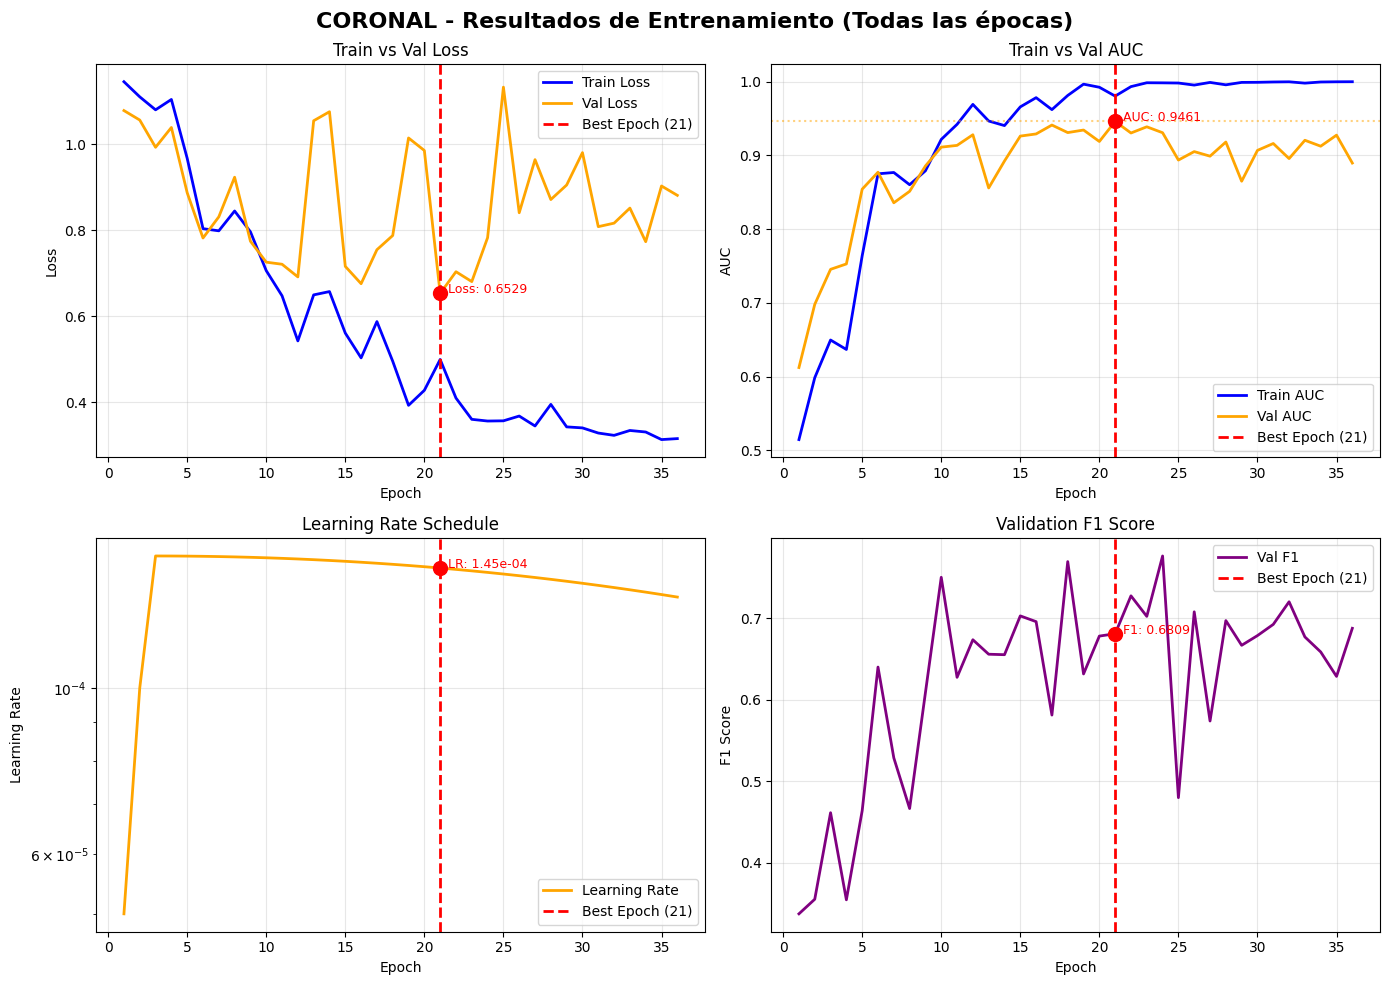

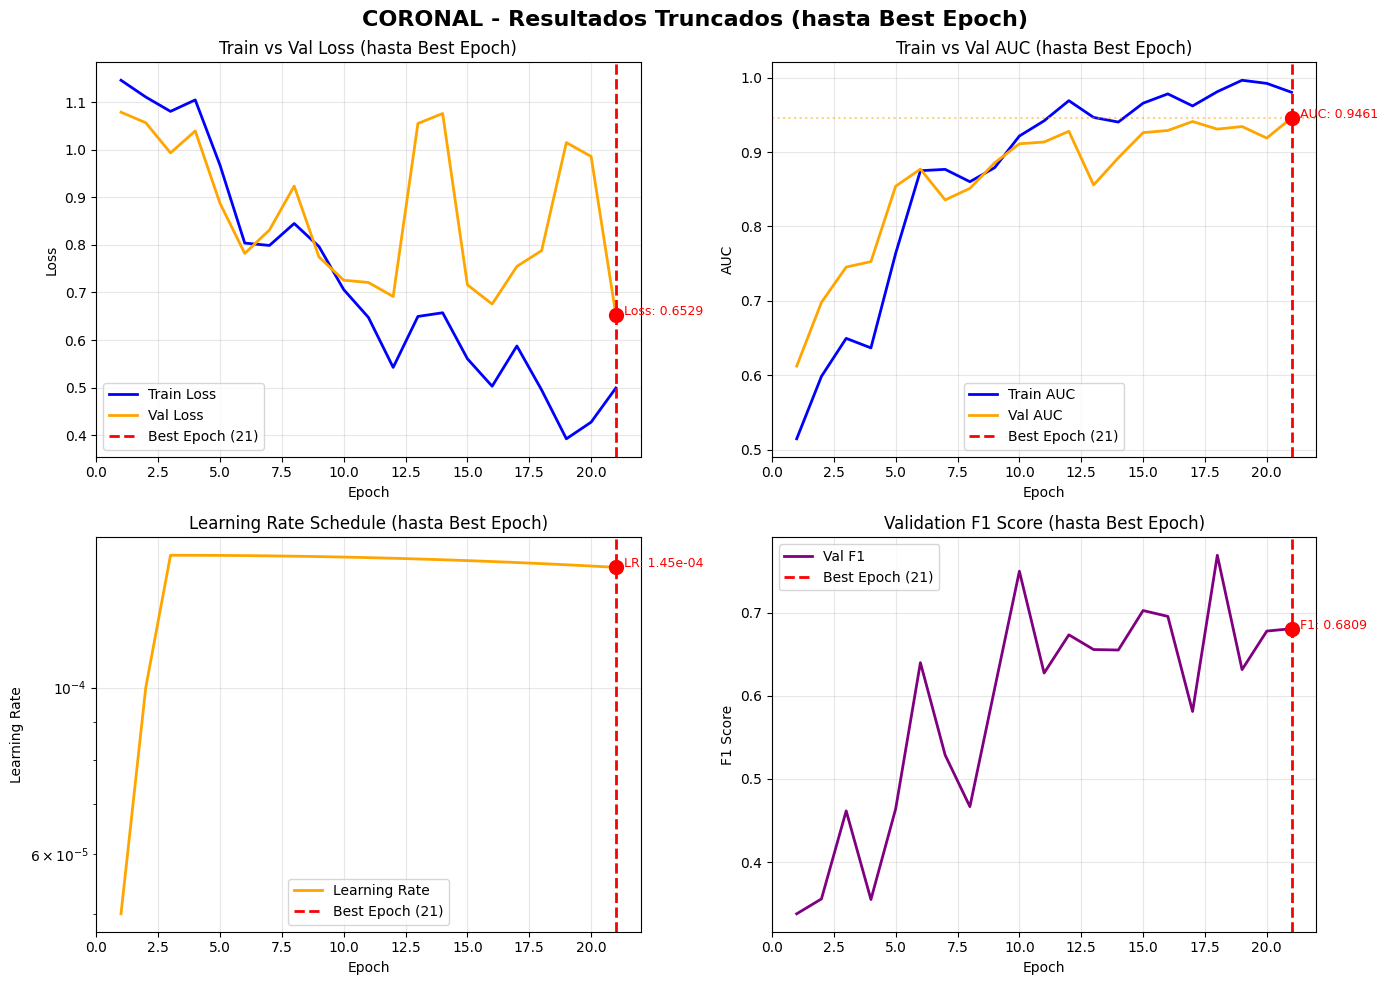

✅ Gráficos generados para CORONAL


In [8]:
# ==========================================
# VISUALIZACIÓN DE RESULTADOS
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# Encontrar la mejor época
best_epoch_idx = np.argmax(history['val_auc'])
best_epoch = best_epoch_idx + 1

# Obtener métricas de la mejor época
best_auc = history['val_auc'][best_epoch_idx]
best_f1 = history['val_f1'][best_epoch_idx]
best_loss = history['val_loss_objective'][best_epoch_idx]
best_train_loss = history['train_loss'][best_epoch_idx]
best_lr = history['learning_rates'][best_epoch_idx]

print(f"\n{'='*80}")
print(f"📊 RESULTADOS DE LA MEJOR ÉPOCA: {best_epoch}")
print(f"{'='*80}")
print(f"✓ Val AUC:        {best_auc:.4f}")
print(f"✓ Val F1:         {best_f1:.4f}")
print(f"✓ Val Loss:       {best_loss:.4f}")
print(f"✓ Train Loss:     {best_train_loss:.4f}")
print(f"✓ Learning Rate:  {best_lr:.2e}")
print(f"{'='*80}\n")

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{plane.upper()} - Resultados de Entrenamiento (Todas las épocas)', fontsize=16, fontweight='bold')

# 1. Train vs Val Loss
ax = axes[0, 0]
ax.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss', linewidth=2, color='blue')
ax.plot(range(1, len(history['val_loss_objective']) + 1), history['val_loss_objective'], label='Val Loss', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_loss], color='red', s=100, zorder=5)
ax.text(best_epoch, best_loss, f'  Loss: {best_loss:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Train vs Val Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. AUC - TRAIN AZUL, VAL NARANJA
ax = axes[0, 1]
ax.plot(range(1, len(history['train_auc']) + 1), history['train_auc'], label='Train AUC', linewidth=2, color='blue')
ax.plot(range(1, len(history['val_auc']) + 1), history['val_auc'], label='Val AUC', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.axhline(max(history['val_auc']), color='orange', linestyle=':', alpha=0.5)
ax.scatter([best_epoch], [best_auc], color='red', s=100, zorder=5)
ax.text(best_epoch, best_auc, f'  AUC: {best_auc:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('Train vs Val AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Learning Rate
ax = axes[1, 0]
ax.plot(range(1, len(history['learning_rates']) + 1), history['learning_rates'], label='Learning Rate', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_lr], color='red', s=100, zorder=5)
ax.text(best_epoch, best_lr, f'  LR: {best_lr:.2e}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. F1 Score
ax = axes[1, 1]
ax.plot(range(1, len(history['val_f1']) + 1), history['val_f1'], label='Val F1', linewidth=2, color='purple')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_f1], color='red', s=100, zorder=5)
ax.text(best_epoch, best_f1, f'  F1: {best_f1:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1 Score')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICOS TRUNCADOS (hasta mejor época)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{plane.upper()} - Resultados Truncados (hasta Best Epoch)', fontsize=16, fontweight='bold')

# 1. Train vs Val Loss (Truncado)
ax = axes[0, 0]
ax.plot(range(1, best_epoch + 1), history['train_loss'][:best_epoch], label='Train Loss', linewidth=2, color='blue')
ax.plot(range(1, best_epoch + 1), history['val_loss_objective'][:best_epoch], label='Val Loss', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_loss], color='red', s=100, zorder=5)
ax.text(best_epoch, best_loss, f'  Loss: {best_loss:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Train vs Val Loss (hasta Best Epoch)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. AUC (Truncado) - TRAIN AZUL, VAL NARANJA
ax = axes[0, 1]
ax.plot(range(1, best_epoch + 1), history['train_auc'][:best_epoch], label='Train AUC', linewidth=2, color='blue')
ax.plot(range(1, best_epoch + 1), history['val_auc'][:best_epoch], label='Val AUC', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.axhline(max(history['val_auc'][:best_epoch]), color='orange', linestyle=':', alpha=0.5)
ax.scatter([best_epoch], [best_auc], color='red', s=100, zorder=5)
ax.text(best_epoch, best_auc, f'  AUC: {best_auc:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('Train vs Val AUC (hasta Best Epoch)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Learning Rate (Truncado)
ax = axes[1, 0]
ax.plot(range(1, best_epoch + 1), history['learning_rates'][:best_epoch], label='Learning Rate', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_lr], color='red', s=100, zorder=5)
ax.text(best_epoch, best_lr, f'  LR: {best_lr:.2e}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule (hasta Best Epoch)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. F1 Score (Truncado)
ax = axes[1, 1]
ax.plot(range(1, best_epoch + 1), history['val_f1'][:best_epoch], label='Val F1', linewidth=2, color='purple')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_f1], color='red', s=100, zorder=5)
ax.text(best_epoch, best_f1, f'  F1: {best_f1:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1 Score (hasta Best Epoch)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✅ Gráficos generados para {plane.upper()}")

## 6️⃣ Entrenar AXIAL

In [9]:
plane = 'axial'
print(f"\n{'='*80}")
print(f"🔄 ENTRENANDO: {plane.upper()}")
print(f"{'='*80}\n")

# Cargar configuración
cfg = PLANE_SPECIFIC_CONFIG[plane]
aug_mode = AUGMENTATION_MODE_PER_PLANE[plane]
plane_pooling_mode = PLANE_CONFIG[plane].get('pooling_mode', 'attention')

# Crear datasets
train_indices_path = SLICE_INDICES_DIR / f"train_{plane}_indices.json"
val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"

train_dataset = OptimizedMRNetDataset(
    csv_path=DATA_PATH / 'train-acl.csv',
    data_root=DATA_PATH / 'train',
    plane=plane,
    indices_cache_path=train_indices_path,
    augmentation_mode=aug_mode
)

val_dataset = OptimizedMRNetDataset(
    csv_path=DATA_PATH / 'val-acl.csv',
    data_root=DATA_PATH / 'val',
    plane=plane,
    indices_cache_path=val_indices_path,
    augmentation_mode=None,
    transform=get_val_test_transform()
)

# Crear DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"✓ DataLoaders creados:")
print(f"  Train: {len(train_loader)} batches ({len(train_dataset)} casos)")
print(f"  Val: {len(val_loader)} batches ({len(val_dataset)} casos)\n")

# Crear modelo
model = ViTMultiSliceClassifier(
    model_name=VIT_MODEL_NAME,
    num_classes=NUM_CLASSES,
    pretrained=True,
    pooling_mode=plane_pooling_mode,
    dropout_input=cfg['dropout_input'],
    dropout_dense=cfg['dropout_dense']
)

model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
model = model.to(device)

print(f"✓ Modelo ViT en GPUs: {VIT_GPU_IDS}\n")

# Entrenar
history, best_auc, best_f1 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    device=device,
    save_dir=CHECKPOINT_DIR,
    plane_name=plane,
    learning_rate=cfg['learning_rate'],
    weight_decay=cfg['weight_decay'],
    label_smoothing=cfg.get('label_smoothing', 0.05),
    use_scheduler=cfg.get('use_scheduler', False),
    use_grad_clip=cfg.get('use_grad_clip', False),
    early_stopping_patience=cfg.get('early_stopping_patience', 25),
    dropout_input=cfg['dropout_input'],
    dropout_dense=cfg['dropout_dense'],
    augmentation_mode=aug_mode,
    use_wandb=USE_WANDB,
    warmup_epochs=cfg.get('warmup_epochs', 3)
)


print(f"\n{'='*80}")
print(f"✅ AXIAL COMPLETADO")
print(f"   Best AUC: {best_auc:.4f}")
print(f"   Best F1: {best_f1:.4f}")
print(f"{'='*80}\n")


🔄 ENTRENANDO: AXIAL

✓ Dataset cargado: 875 casos
  Plane: axial
  Augmentation: aggressive
  Índices cacheados: ../data/slice_indices_final/train_axial_indices.json
✓ Dataset cargado: 188 casos
  Plane: axial
  Augmentation: None (usando transform directo)
  Índices cacheados: ../data/slice_indices_final/val_axial_indices.json
✓ DataLoaders creados:
  Train: 14 batches (875 casos)
  Val: 3 batches (188 casos)



Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Modelo ViT en GPUs: [0, 1, 2]


ENTRENANDO MODELO: AXIAL
LR=0.00015, WD=0.00045, Scheduler=True, GradClip=True
Dropout: Input=0.35, Dense=0.25
Augmentation: aggressive

📊 Class imbalance (pos_weight): 3.7814
   (Ratio negatives:positives)



✓ Weights & Biases inicializado para axial

Epoch 1/150 (LR=3.00e-05): Train: Loss=1.1372, AUC=0.5870 | Val: Loss=1.1011, AUC=0.6584, F1=0.3279 ✓ Best AUC!
Epoch 2/150 (LR=6.00e-05): Train: Loss=1.0385, AUC=0.7544 | Val: Loss=1.0163, AUC=0.7537, F1=0.4815 ✓ Best AUC!
Epoch 3/150 (LR=9.00e-05): Train: Loss=1.0279, AUC=0.7550 | Val: Loss=0.9813, AUC=0.7935, F1=0.5049 ✓ Best AUC!
Epoch 4/150 (LR=1.20e-04): Train: Loss=0.9221, AUC=0.8500 | Val: Loss=0.9817, AUC=0.7995, F1=0.5192 ✓ Best AUC!
Epoch 5/150 (LR=1.50e-04): Train: Loss=0.9154, AUC=0.8530 | Val: Loss=0.9935, AUC=0.8193, F1=0.4583 ✓ Best AUC!
Epoch 6/150 (LR=1.50e-04): Train: Loss=0.9195, AUC=0.8519 | Val: Loss=1.0732, AUC=0.8282, F1=0.4380 ✓ Best AUC!
Epoch 7/150 (LR=1.50e-04): Train: Loss=0.9096, AUC=0.8609 | Val: Loss=0.9173, AUC=0.8609, F1=0.5684 ✓ Best AUC!
Epoch 8/150 (LR=1.50e-04): Train: Loss=0.8522, AUC=0.8836 | Val: Loss=0.8606, AUC=0.8927, F1=0.5833 ✓ Best AUC!
Epoch 9/150 (LR=1.50e-04): Train: Loss=0.8161, AUC=0.9139 | 

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
learning_rate,▁▃▄▆██████████████████████
train_auc,▁▄▄▆▆▆▆▆▇▇▇▇█▇██████▇█████
train_loss,█▇▇▆▅▅▅▅▄▄▃▄▃▃▂▃▂▃▁▂▃▂▁▁▁▁
val_auc,▁▃▄▄▅▅▆▇████▇▇██▆▇▇█▇█▇█▆▇
val_f1,▁▃▄▄▃▃▅▅▄▇▅▇▇▇▇▇▅▇▇▆▆██▇▇▇
val_loss,█▆▆▆▆▇▄▃▃▁▃▄▄▃▃▃▇▂▄▆▆▂▃▂▅▄
best_auc,0.94591
best_f1,0.56911
epoch,26
learning_rate,0.00014



✅ AXIAL COMPLETADO
   Best AUC: 0.9459
   Best F1: 0.5691




📊 RESULTADOS DE LA MEJOR ÉPOCA: 11
✓ Val AUC:        0.9459
✓ Val F1:         0.5691
✓ Val Loss:       0.8762
✓ Train Loss:     0.7383
✓ Learning Rate:  1.49e-04



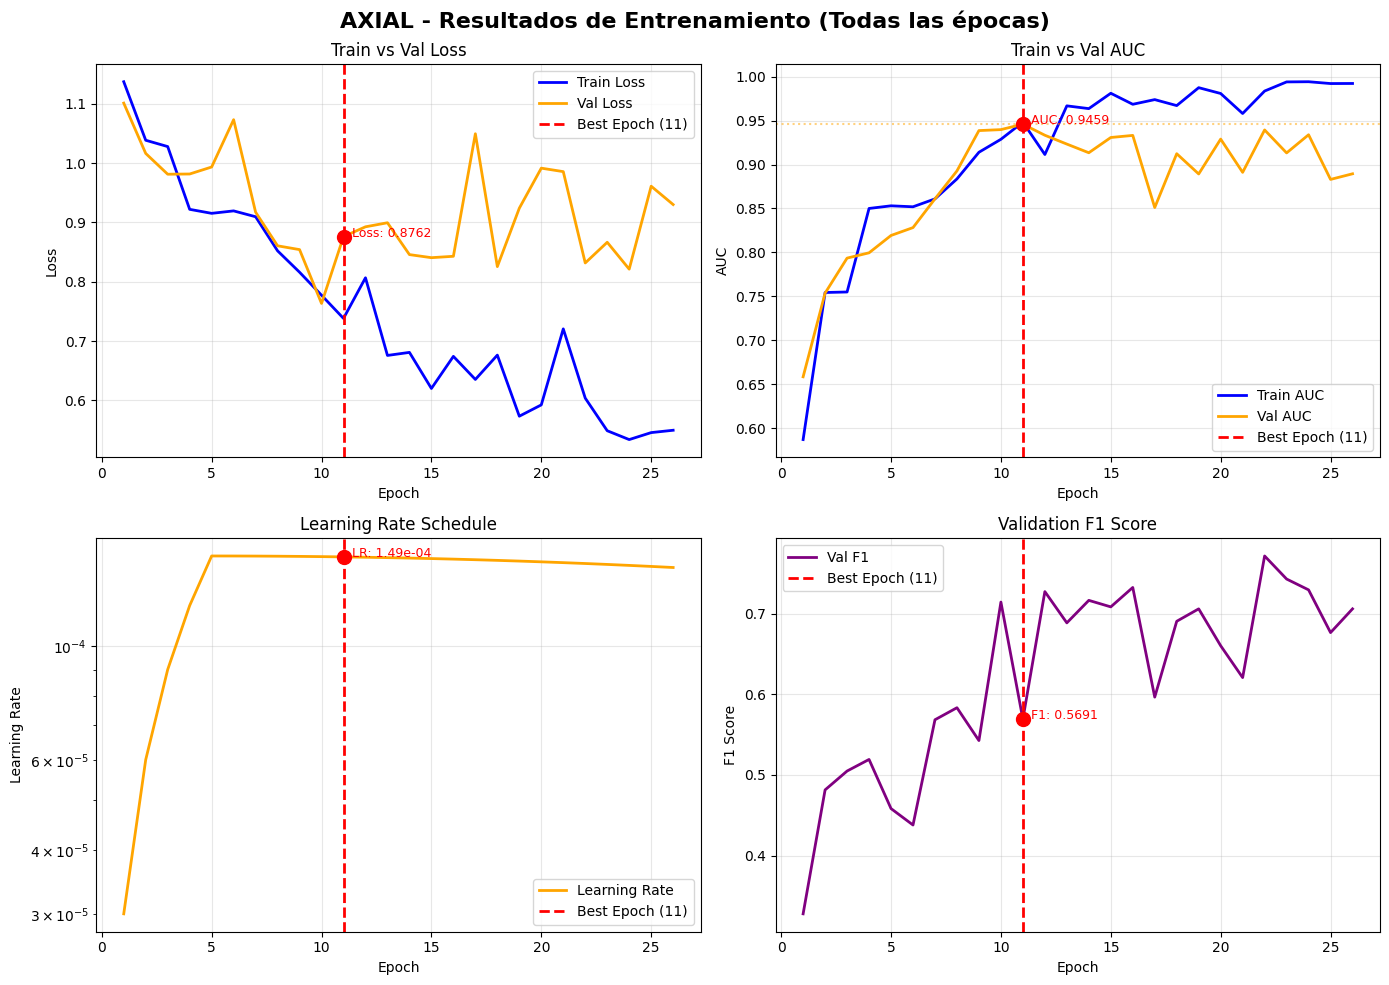

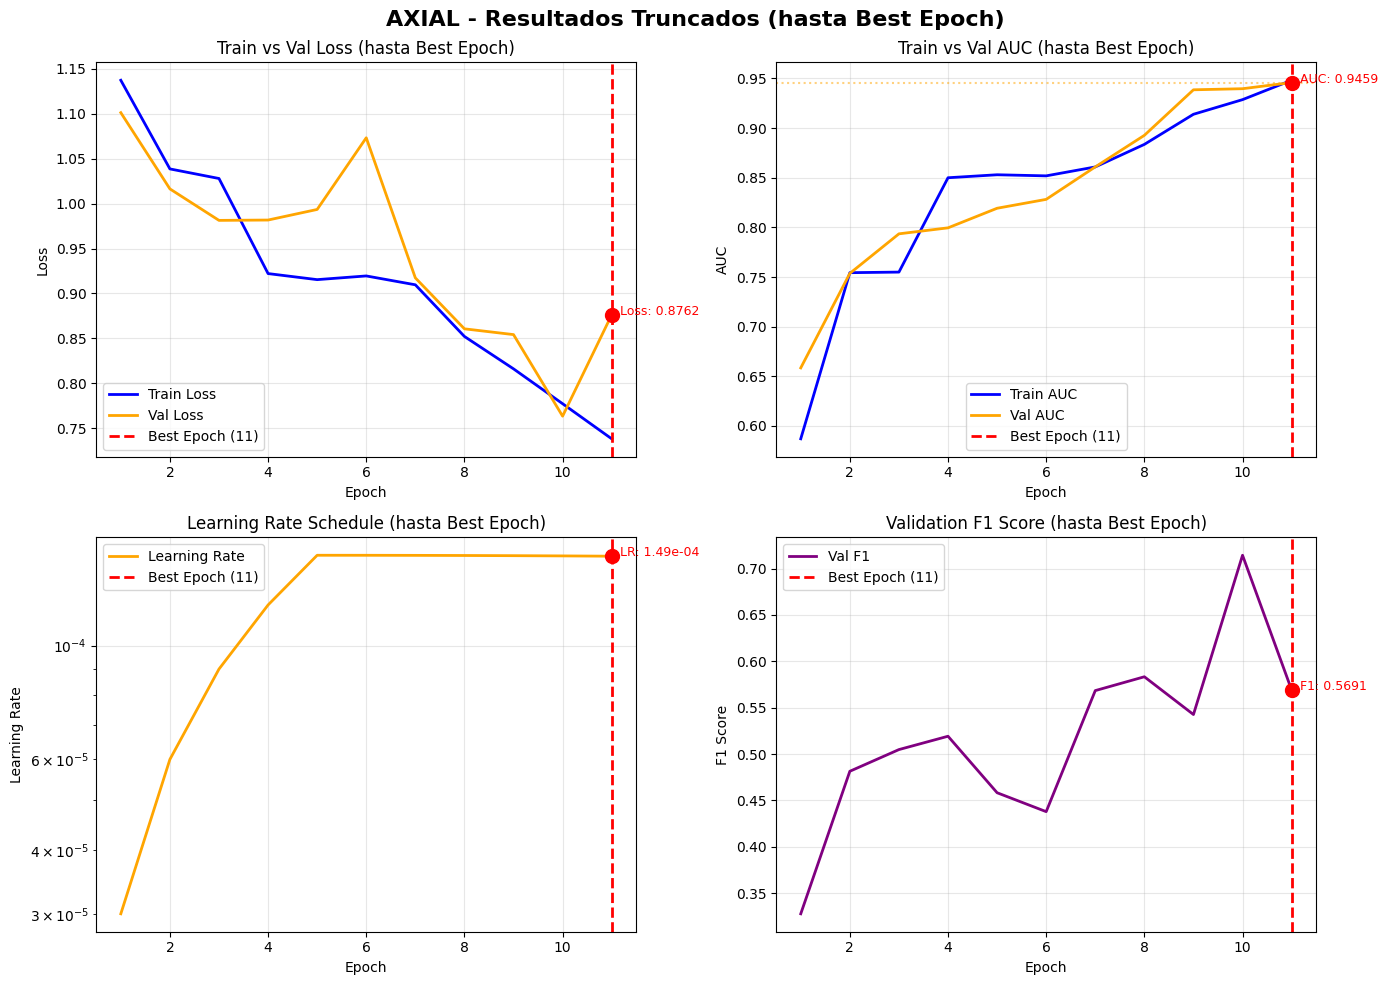

✅ Gráficos generados para AXIAL


In [10]:
# ==========================================
# VISUALIZACIÓN DE RESULTADOS
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# Encontrar la mejor época
best_epoch_idx = np.argmax(history['val_auc'])
best_epoch = best_epoch_idx + 1

# Obtener métricas de la mejor época
best_auc = history['val_auc'][best_epoch_idx]
best_f1 = history['val_f1'][best_epoch_idx]
best_loss = history['val_loss_objective'][best_epoch_idx]
best_train_loss = history['train_loss'][best_epoch_idx]
best_lr = history['learning_rates'][best_epoch_idx]

print(f"\n{'='*80}")
print(f"📊 RESULTADOS DE LA MEJOR ÉPOCA: {best_epoch}")
print(f"{'='*80}")
print(f"✓ Val AUC:        {best_auc:.4f}")
print(f"✓ Val F1:         {best_f1:.4f}")
print(f"✓ Val Loss:       {best_loss:.4f}")
print(f"✓ Train Loss:     {best_train_loss:.4f}")
print(f"✓ Learning Rate:  {best_lr:.2e}")
print(f"{'='*80}\n")

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{plane.upper()} - Resultados de Entrenamiento (Todas las épocas)', fontsize=16, fontweight='bold')

# 1. Train vs Val Loss
ax = axes[0, 0]
ax.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss', linewidth=2, color='blue')
ax.plot(range(1, len(history['val_loss_objective']) + 1), history['val_loss_objective'], label='Val Loss', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_loss], color='red', s=100, zorder=5)
ax.text(best_epoch, best_loss, f'  Loss: {best_loss:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Train vs Val Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. AUC - TRAIN AZUL, VAL NARANJA
ax = axes[0, 1]
ax.plot(range(1, len(history['train_auc']) + 1), history['train_auc'], label='Train AUC', linewidth=2, color='blue')
ax.plot(range(1, len(history['val_auc']) + 1), history['val_auc'], label='Val AUC', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.axhline(max(history['val_auc']), color='orange', linestyle=':', alpha=0.5)
ax.scatter([best_epoch], [best_auc], color='red', s=100, zorder=5)
ax.text(best_epoch, best_auc, f'  AUC: {best_auc:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('Train vs Val AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Learning Rate
ax = axes[1, 0]
ax.plot(range(1, len(history['learning_rates']) + 1), history['learning_rates'], label='Learning Rate', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_lr], color='red', s=100, zorder=5)
ax.text(best_epoch, best_lr, f'  LR: {best_lr:.2e}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. F1 Score
ax = axes[1, 1]
ax.plot(range(1, len(history['val_f1']) + 1), history['val_f1'], label='Val F1', linewidth=2, color='purple')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_f1], color='red', s=100, zorder=5)
ax.text(best_epoch, best_f1, f'  F1: {best_f1:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1 Score')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICOS TRUNCADOS (hasta mejor época)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{plane.upper()} - Resultados Truncados (hasta Best Epoch)', fontsize=16, fontweight='bold')

# 1. Train vs Val Loss (Truncado)
ax = axes[0, 0]
ax.plot(range(1, best_epoch + 1), history['train_loss'][:best_epoch], label='Train Loss', linewidth=2, color='blue')
ax.plot(range(1, best_epoch + 1), history['val_loss_objective'][:best_epoch], label='Val Loss', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_loss], color='red', s=100, zorder=5)
ax.text(best_epoch, best_loss, f'  Loss: {best_loss:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Train vs Val Loss (hasta Best Epoch)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. AUC (Truncado) - TRAIN AZUL, VAL NARANJA
ax = axes[0, 1]
ax.plot(range(1, best_epoch + 1), history['train_auc'][:best_epoch], label='Train AUC', linewidth=2, color='blue')
ax.plot(range(1, best_epoch + 1), history['val_auc'][:best_epoch], label='Val AUC', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.axhline(max(history['val_auc'][:best_epoch]), color='orange', linestyle=':', alpha=0.5)
ax.scatter([best_epoch], [best_auc], color='red', s=100, zorder=5)
ax.text(best_epoch, best_auc, f'  AUC: {best_auc:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('Train vs Val AUC (hasta Best Epoch)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Learning Rate (Truncado)
ax = axes[1, 0]
ax.plot(range(1, best_epoch + 1), history['learning_rates'][:best_epoch], label='Learning Rate', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_lr], color='red', s=100, zorder=5)
ax.text(best_epoch, best_lr, f'  LR: {best_lr:.2e}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule (hasta Best Epoch)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. F1 Score (Truncado)
ax = axes[1, 1]
ax.plot(range(1, best_epoch + 1), history['val_f1'][:best_epoch], label='Val F1', linewidth=2, color='purple')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_f1], color='red', s=100, zorder=5)
ax.text(best_epoch, best_f1, f'  F1: {best_f1:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1 Score (hasta Best Epoch)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✅ Gráficos generados para {plane.upper()}")

## 7️⃣ Resumen Final

In [20]:
print(f"\n{'='*80}")
print(f"✅ ENTRENAMIENTO COMPLETADO PARA LOS 3 PLANOS")
print(f"{'='*80}")
print(f"\nCheckpoints guardados en: {CHECKPOINT_DIR}")
print(f"\nPróximos pasos:")
print(f"  1. Cargar los mejores modelos")
print(f"  2. Evaluar en test set")
print(f"  3. Crear ensemble multi-plano")
print(f"  4. Calibración de temperaturas (Temperature Scaling)")
print(f"{'='*80}\n")


✅ ENTRENAMIENTO COMPLETADO PARA LOS 3 PLANOS

Checkpoints guardados en: ../checkpoints/acl_classifier_final

Próximos pasos:
  1. Cargar los mejores modelos
  2. Evaluar en test set
  3. Crear ensemble multi-plano
  4. Calibración de temperaturas (Temperature Scaling)

